# Network propagation development

The notebook currently covers how results from a AnnData/MuData object can be added to a cpr_graph to setup network-based inference. The general strategy is to:
1. pull out a pd.DataFrame containing feature-level measures of interest along with feature metadata.
2. These are then mapped on the species ids in an sbml_dfs model by shared on ontology, disambiguated (to handle mapping of multiple features to the same s_id), and s_id-indexed results are embedded in the sbml_dfs as a table in species_data
3. attributes of interrest are then passed from the sbml_dfs model into the graph.

This example uses real MuData results but only a small sbml_dfs object which has uniprot but not ENSG identifiers. This makes things easy to work with but a genome-scale graph will need to be used for a real analysis.

Reflecting on the current functionality,

(1) is not too hard but the interface can probably be cleaned up as we should have a function which applies 1-3 in a single call.
(2) is in pretty good shape following a LOT of new functionality being added to napistu-py for handling many-to-one mappings and wide/nested formats for identifiers.
(3) will need some better functionality since the reaction_attrs syntax is pretty cryptic but the core functionality is all there.

Next, steps will be develop basic PPR functionality.

In [1]:
import os
import re
from types import SimpleNamespace

import mudata as md
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from napistu.sbml_dfs_core import SBML_dfs
from napistu import utils as napistu_utils
from napistu.gcs import downloads
from napistu.matching import mount
from napistu.network import net_create
from napistu.network.ng_core import NapistuGraph
from napistu.network import net_propagation
from napistu.network import data_handling
from napistu.network import ng_utils
from napistu.scverse.loading import prepare_anndata_results_df
from napistu.scverse.loading import prepare_mudata_results_df
from napistu.constants import ONTOLOGIES
from napistu.matching.constants import BIND_DICT_OF_WIDE_RESULTS_STRATEGIES_LIST

from shackett_utils.statistics import hypothesis_testing
from shackett_utils.statistics import multi_model_fitting

# setup logging
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

# paths
PROJECT_DIR =  os.path.expanduser("~/Desktop/DATA/Forny2023")
SUPPLEMENTAL_DATA_DIR = os.path.join(PROJECT_DIR, "input")
CACHE_DIR = os.path.join(PROJECT_DIR, "cache")
NAPISTU_DATA_DIR = os.path.expanduser("~/Desktop/DATA/napistu_data")

# inputs
# model to download from GCS and store in NAPISTU_DATA_DIR
NAPISTU_ASSET = "human_consensus_w_distances"
# H5Mu file containing the optimal model from MOFA+ and regression summaries
OPTIMAL_MODEL_H5MU_OUTFILE = "mofa_optimal_model.h5mu"

# intermediate files
PPR_NULL_CACHE_OUTFILE = "ppr_null_cache.tsv"

# outputs
PPR_RESULTS_OUTFILE = "ppr_results.tsv"
ANNOTATED_VERTICES_OUTFILE = "annotated_vertices.tsv"
SBML_DFS_W_DATA_OUTFILE = "sbml_dfs_w_data.pkl"
NAPISTU_GRAPH_W_DATA_OUTFILE = "napistu_graph_w_data.pkl"

# Paths to input/output files
OPTIMAL_MODEL_H5MU_PATH = os.path.join(CACHE_DIR, OPTIMAL_MODEL_H5MU_OUTFILE)
PPR_NULL_TMP_PATH = os.path.join(CACHE_DIR, PPR_NULL_CACHE_OUTFILE)
PPR_RESULTS_PATH = os.path.join(PROJECT_DIR, PPR_RESULTS_OUTFILE)
ANNOTATED_VERTICES_PATH = os.path.join(PROJECT_DIR, ANNOTATED_VERTICES_OUTFILE)
SBML_DFS_W_DATA_PATH = os.path.join(PROJECT_DIR, SBML_DFS_W_DATA_OUTFILE)
NAPISTU_GRAPH_W_DATA_PATH = os.path.join(PROJECT_DIR, NAPISTU_GRAPH_W_DATA_OUTFILE)

# dataset metadata
FORNY_MODALITIES = SimpleNamespace(
    TRANSCRIPTOMICS = "transcriptomics",
    PROTEOMICS = "proteomics"
)

# Napistu controlled vocabulary
FORNY_ONTOLOGIES = SimpleNamespace(
    ENSEMBL_GENE = ONTOLOGIES.ENSEMBL_GENE,
    UNIPROT = ONTOLOGIES.UNIPROT
)

FORNY_DEFS = SimpleNamespace(
    PCS = "PCs",
    LFS = "LFs"
)

PCS_OF_INTEREST = ["PC1", "PC2", "PC3"]
LFS_OF_INTEREST = ["LF1", "LF2", "LF3", "LF4", "LF5"]
FDR_CUTOFF = 0.1 # just used for hard thresholding in this analysis
N_NULL_SAMPLES = 100

MUDATA_ONTOLOGIES = {
    # these dicts indicate the ontology that we want to match against for each modality
    # and indicate that this ontology's identifiers are present in the .var table's index
    FORNY_MODALITIES.TRANSCRIPTOMICS :
        {
            "ontologies" : [FORNY_ONTOLOGIES.ENSEMBL_GENE],
            "index_which_ontology" : FORNY_ONTOLOGIES.ENSEMBL_GENE
        },
    FORNY_MODALITIES.PROTEOMICS :
        {
            "ontologies" : [FORNY_ONTOLOGIES.UNIPROT],
            "index_which_ontology" : FORNY_ONTOLOGIES.UNIPROT
        }
}

# results from loose tables
VZ_LMM_RESULTS = {
    FORNY_MODALITIES.TRANSCRIPTOMICS: "diff_exp_lmm_rnaseq_pathwayact_all_annotout.txt",
    FORNY_MODALITIES.PROTEOMICS: "diff_exp_lmm_prot_pathwayact_all_annotout.txt"
}

INDICATOR_STR = 'is_{modality}'

# regression terms to add from var table
PPR_LINEAR_PHENOTYPES = {"MMA_urine", "OHCblPlus", "responsive_to_acute_treatment"}
PPR_SMOOTH_PHENOTYPES = {"date_freezing", "proteomics_runorder"}

VAR_VARS = list()
for phenotype in PPR_LINEAR_PHENOTYPES:
    VAR_VARS.append(f"est_{phenotype}")
    VAR_VARS.append(f"stat_{phenotype}")
    # using -log10p since normal p- and q-values will underflow
    VAR_VARS.append(f"log10_p_{phenotype}")
    VAR_VARS.append(f"q_{phenotype}")
for phenotype in PPR_SMOOTH_PHENOTYPES:
    VAR_VARS.append(f"q_{phenotype}")

# tables where attributes are added to the sbml_dfs
LOOSE_DATA_TBL_STR = '{modality}_loose_data'
PROTEOMICS_PC_TABLE_STR =  "proteomics_pcs"
MODALITY_VAR_LEVEL_RESULTS_TBL_STR ="{modality}_var_level_results"
VAR_LEVEL_RESULTS_TBL_STR = "var_level_results"

OVERWRITE = False


In [2]:
# this will download the sbml_dfs, napistu_graph, and species_identifiers from a public GCS bucket
# or if they already exist in the NAPISTU_DATA_DIR, it will just set the path to the existing asset
sbml_dfs_path = downloads.load_public_napistu_asset(
    asset = NAPISTU_ASSET,
    data_dir = NAPISTU_DATA_DIR,
    subasset = "sbml_dfs",
    overwrite = True
)

napistu_graph_path = downloads.load_public_napistu_asset(
    asset = NAPISTU_ASSET,
    data_dir = NAPISTU_DATA_DIR,
    subasset = "napistu_graph"
)

species_identifiers_path = downloads.load_public_napistu_asset(
    asset = NAPISTU_ASSET,
    data_dir = NAPISTU_DATA_DIR,
    subasset = "species_identifiers"
)


INFO:napistu.gcs.downloads:Removed asset archive: /Users/sean/Desktop/DATA/napistu_data/human_consensus_w_distances.tar.gz
INFO:napistu.gcs.downloads:Removed extracted asset directory: /Users/sean/Desktop/DATA/napistu_data/human_consensus_w_distances
INFO:napistu.gcs.downloads:Downloading human_consensus_w_distances.tar.gz to /Users/sean/Desktop/DATA/napistu_data/human_consensus_w_distances.tar.gz
INFO:napistu.gcs.downloads:Download URI: https://storage.googleapis.com/shackett-napistu-public/human_consensus_w_distances.tar.gz
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): storage.googleapis.com:443
DEBUG:urllib3.connectionpool:https://storage.googleapis.com:443 "GET /shackett-napistu-public/human_consensus_w_distances.tar.gz HTTP/1.1" 200 2471012228
INFO:napistu.utils:Archive downloaded and untared to /Users/sean/Desktop/DATA/napistu_data/human_consensus_w_distances


In [3]:
# ~2 min load
sbml_dfs = SBML_dfs.from_pickle(sbml_dfs_path)

napistu_graph = NapistuGraph.from_pickle(napistu_graph_path)

species_identifiers = pd.read_csv(species_identifiers_path, delimiter = "\t")

ng_utils.validate_assets(
    sbml_dfs = sbml_dfs,
    napistu_graph = napistu_graph,
    identifiers_df = species_identifiers
)

In [4]:
sbml_dfs.compartmentalized_species.loc["SC00002412"]

sc_name                                                MUT
s_id                                             S00002412
c_id                                             C00000000
sc_Source    <napistu.source.Source object at 0xa9d85a9d0>
Name: SC00002412, dtype: object

In [5]:
# lets load the Forny results so we can try adding a few different types of tables to the sbml_dfs
mdata = md.read_h5mu(OPTIMAL_MODEL_H5MU_PATH)

# create an indicator which just highlights which modalities are present in the mdata
# this will propagate this indiciator to vertices in the graph which is useful for generating
# a mask for constructing vertices null distributions
ADATA_LEVEL_VARS = dict()
for modality in mdata.mod_names:
    indicator_var = INDICATOR_STR.format(modality=modality)
    # add to var table
    mdata[modality].var[indicator_var] = 1
    # indicate that this should be added to the sbml_dfs later
    ADATA_LEVEL_VARS[modality] = [indicator_var]

DEBUG:h5py._conv:Creating converter from 3 to 5


## Adding genome-scale datasets

To use an 'omic dataset in Napistu, we want to:
1. mount the dataset on the pathway `sbml_dfs`. This entails:
    - matching systematic identifiers between the dataset and pathway to connect 'omic features to Napistu `species`.
    - resolve many-to-1 mappings (e.g., where 2+ features match the same species).
    - create a table with unique species ids as the index with variable from the dataset.
    - add this to the `species_data` attriute of the `sbml_dfs`. Multiple tables and/or datasets can be added to `species_data`.
2. pass variables from one or more `species_data` tables to a `napistu_graph`'s vertices with `net_create._add_graph_species_attribute`. Variables can be transformed (e.g., to make them non-negative for personalized pagerank) at this point (or this could be done before step (1)).
3. use these verterx attributes for downstream analysis (e.g., using it in the reset_proportional_to parameters of PPR).

Step (1) needs to be adapted depending on how datasets are organized. The currently, supported inputs are:
- `pd.DataFrame` objects which including 1+ systematic identifiers
- `anndata.AnnData` objects where the `var` table provided identifiers, and feature-level summaries come from either the `var`, `varm` or `X` tables.
- `mudata.MuData` objects containing multiple `AnnData` objects where `var` and `varm` attributes can be defined across multiple datasets.

We'll provide an examples using each of these inputs

### Loading results from a pd.DataFrame

In [6]:
sideloaded_data_path = {x : os.path.join(SUPPLEMENTAL_DATA_DIR, y) for x, y in VZ_LMM_RESULTS.items()}

assert all([os.path.isfile(x) for x in sideloaded_data_path.values()])

sideloaded_data = {
    x : pd.read_csv(y, delimiter= "\t") for x, y in sideloaded_data_path.items()
}

In [7]:
for modality in sideloaded_data.keys():
    x = (
        sideloaded_data[modality][["ensembl", "chi_sq", "pval", "fdr"]]
        .assign(sideloaded = 1)
        .rename(columns = {"chi_sq" : "chisq_sideloaded", "pval" : "pval_sideloaded", "fdr" : "fdr_sideloaded"})
    )

    mount.bind_wide_results(
        sbml_dfs,
        x,
        LOOSE_DATA_TBL_STR.format(modality = modality),
        # map columns to Napistu's controlled vocabulary (constants.ONTOLOGIES)
        ontologies = {"ensembl" : FORNY_ONTOLOGIES.ENSEMBL_GENE},
        species_identifiers = species_identifiers,
        dogmatic = False,
        verbose = True
    )

DEBUG:napistu.matching.species:Validated ontology columns: {'ensembl_gene'}
INFO:napistu.matching.species:Using columns as results: ['chisq_sideloaded', 'fdr_sideloaded', 'pval_sideloaded', 'feature_id', 'sideloaded']
DEBUG:napistu.matching.species:Final long format shape: (14749, 7)
DEBUG:napistu.matching.species:Matching 14749 features to 24340 species for ontology ensembl_gene
INFO:napistu.matching.species:Found 15146 total matches across 1 ontologies
INFO:napistu.matching.species:-1.4% change in feature_ids (14544 vs 14749)
INFO:napistu.matching.species:349 s_id(s) map to more than one feature_id.
INFO:napistu.matching.species:Examples of s_id mapping to multiple feature_ids (showing up to 3):
s_id       s_name     
S00000034  ubiquitin C    [3669, 5802, 7104, 8013]
S00000035  ITCH gene                 [8929, 13431]
S00000039  UBE2L3                     [3752, 9356]
Name: feature_id, dtype: object
INFO:napistu.matching.species:416 feature_id(s) map to more than one s_id.
INFO:napis

## Loading Results from an AnnData object

Since the Forny dataset is a multiomics experiment many of the variablges we are interested in will hold a common interpretation across all modalities. For example, the effect size of a term in a regression holds a common meaning as do the loadings from a multi-omic factor analysis (MOFA) decomposition.

But, many datasets will just be a single modality, and even for multiomic datasets we may be interested in exploring the biology of datamodality-specific attributes. An example in this study is the data-modality specific principal component loadings. Since PCA was performed separately on each data modality the principal components will likely be relatively uncorrelated hence it doesn't make much sense to treat the loadings of PCX to one another across modalities. This is definitely the case for this dataset - PC1 of the proteomics data largely reflects a chromatography-driven technical batch effect which is not seen in the transcriptomics data. To more directly explore this proteomics batch effect we can pull PC1 out of its `AnnData` table.

In [8]:
anndata_results_df = prepare_anndata_results_df(
    mdata[FORNY_MODALITIES.PROTEOMICS],
    table_type = "varm",
    table_name = FORNY_DEFS.PCS,
    results_attrs = PCS_OF_INTEREST,
    index_which_ontology = FORNY_ONTOLOGIES.UNIPROT,
    table_colnames = [f"PC{i+1}" for i in range(0, mdata[FORNY_MODALITIES.PROTEOMICS].varm[FORNY_DEFS.PCS].shape[1])]
)

mount.bind_wide_results(
    sbml_dfs,
    anndata_results_df,
    PROTEOMICS_PC_TABLE_STR,
    species_identifiers = species_identifiers,
    ontologies = FORNY_ONTOLOGIES.UNIPROT
)

DEBUG:napistu.scverse.loading:_select_results_attrs called with table_type=varm, results_attrs=['PC1', 'PC2', 'PC3']
INFO:napistu.matching.species:Auto-detected ontology columns: {'uniprot'}
DEBUG:napistu.matching.species:Validated ontology columns: {'uniprot'}
DEBUG:napistu.matching.species:Validated ontology columns: {'uniprot'}
INFO:napistu.matching.species:Using columns as results: ['PC3', 'PC2', 'feature_id', 'PC1']
DEBUG:napistu.matching.species:Final long format shape: (4788, 6)
DEBUG:napistu.matching.species:Matching 4788 features to 129139 species for ontology uniprot
INFO:napistu.matching.species:Found 8095 total matches across 1 ontologies


Here's another example where we want to pull out an indicator variable from each modality's `var` table.

In [9]:
for modality in mdata.mod_names:
    anndata_results_df = prepare_anndata_results_df(
        mdata[modality],
        table_type="var",
        index_which_ontology = MUDATA_ONTOLOGIES[modality]["index_which_ontology"],
        results_attrs=ADATA_LEVEL_VARS[modality]
    )

    mount.bind_wide_results(
        sbml_dfs,
        anndata_results_df,
        MODALITY_VAR_LEVEL_RESULTS_TBL_STR.format(modality = modality),
        species_identifiers = species_identifiers,
        ontologies = MUDATA_ONTOLOGIES[modality]["ontologies"]
    )


DEBUG:napistu.scverse.loading:_select_results_attrs called with table_type=var, results_attrs=['is_transcriptomics']
INFO:napistu.matching.species:Auto-detected ontology columns: {'ensembl_gene'}
DEBUG:napistu.matching.species:Validated ontology columns: {'ensembl_gene'}
INFO:napistu.matching.species:Auto-detected ontology columns: {'ensembl_gene'}
DEBUG:napistu.matching.species:Validated ontology columns: {'ensembl_gene'}
INFO:napistu.matching.species:Using columns as results: ['is_transcriptomics', 'feature_id']
DEBUG:napistu.matching.species:Final long format shape: (9134, 4)
DEBUG:napistu.matching.species:Matching 9134 features to 24340 species for ontology ensembl_gene
INFO:napistu.matching.species:Found 9395 total matches across 1 ontologies
DEBUG:napistu.scverse.loading:_select_results_attrs called with table_type=var, results_attrs=['is_proteomics']
INFO:napistu.matching.species:Auto-detected ontology columns: {'uniprot'}
DEBUG:napistu.matching.species:Validated ontology column

In [10]:
# we can look at the species data created thus far
for k, v in sbml_dfs.species_data.items():
    print(k)
    display(napistu_utils.style_df(v.head(5)))


transcriptomics_loose_data


,chisq_sideloaded,pval_sideloaded,fdr_sideloaded,sideloaded,feature_id
s_id,,,,,
S00000001,2.337,0.126,1.000,1.000,8562
S00000005,0.000,0.983,1.000,1.000,4041
S00000009,0.152,0.697,1.000,1.000,2583
S00000013,0.098,0.754,1.000,1.000,86
S00000014,0.426,0.514,1.000,1.000,14504


proteomics_loose_data


,chisq_sideloaded,pval_sideloaded,fdr_sideloaded,sideloaded,feature_id
s_id,,,,,
S00000001,0.117,0.733,1.000,1.000,2210
S00000009,0.009,0.923,1.000,1.000,2037
S00000013,1.060,0.303,1.000,1.000,661
S00000014,0.965,0.326,1.000,1.000,568
S00000018,3.195,0.074,1.000,1.000,3019


proteomics_pcs


,PC1,PC2,PC3,feature_id
s_id,,,,
S00000001,-0.000,-0.013,-0.005,2484
S00000009,-0.003,0.029,-0.035,2303
S00000011,0.005,-0.019,-0.007,730
S00000012,-0.001,-0.023,-0.004,833
S00000013,-0.001,-0.023,-0.004,833


transcriptomics_var_level_results


,is_transcriptomics,feature_id
s_id,,
S00000009,1.000,1660
S00000013,1.000,50
S00000014,1.000,8982
S00000018,1.000,6039
S00000027,1.000,8968


proteomics_var_level_results


,is_proteomics,feature_id
s_id,,
S00000001,1.000,2484
S00000009,1.000,2303
S00000011,1.000,730
S00000012,1.000,833
S00000013,1.000,833


### Loading Results from a MuData object

MuData is a data structure for organizing multiple AnnData objects which can be maninpulated with AnnData-level operations but the combined dataset also has its own attributes which pertain to all data modalities. Napistu provides convenience functions for pulling multi-omic attributes out a MuData object and these can either be stored as a separate attribute for each modality or as a single summary defined over all modalities. The latter workflow may be helpful when combining modalities with non-overlapping ontologies - for example, proteins and metabolites. While, keeping modalities separate may be preferred if multiple modalities would map to the same nodes. For example, working with transcriptomics and proteomics, like in the Forny study, we may want to separately map want to use separate vertex attributes for each modality. This may not be necessary if we are working in "dogmatic" mode where genes, transcripts, and proteins are generally represented as separate nodes, but in non-dogmatic mode these entries are treated equivalently. But, here the network that we are working with was created in non-dogmatic mode ([link](https://github.com/napistu/napistu/blob/26402a440be9d9cb901c1edf371ef0a7e5475e55/dev/create_human_consensus.qmd#L215)).

In [11]:
split_results_tables = prepare_mudata_results_df(
    mdata,
    mudata_ontologies=MUDATA_ONTOLOGIES,
    table_type="varm",
    table_name=FORNY_DEFS.LFS, # this would be autodetected
    results_attrs=LFS_OF_INTEREST,
    table_colnames=[f"LF{i}" for i in range(1, mdata.varm[FORNY_DEFS.LFS].shape[1] + 1)]
)

for k, v in split_results_tables.items():
    print(k)
    display(napistu_utils.style_df(v.head(5)))


DEBUG:napistu.scverse.loading:_select_results_attrs called with table_type=varm, results_attrs=['LF1', 'LF2', 'LF3', 'LF4', 'LF5']
DEBUG:napistu.matching.species:Validated ontology columns: {'ensembl_gene'}
DEBUG:napistu.matching.species:Validated ontology columns: {'uniprot'}


transcriptomics


,ensembl_gene,LF1,LF2,LF3,LF4,LF5
ensembl_gene,,,,,,
ENSG00000187634,ENSG00000187634,-0.132,-0.066,-0.000,-0.106,-0.006
ENSG00000188976,ENSG00000188976,-0.078,0.007,-0.000,-0.092,-0.048
ENSG00000187608,ENSG00000187608,-0.044,0.042,0.000,-0.129,-0.035
ENSG00000188157,ENSG00000188157,-0.017,-0.008,0.000,0.095,-0.198
ENSG00000078808,ENSG00000078808,0.069,-0.001,-0.000,-0.069,-0.021


proteomics


,uniprot,LF1,LF2,LF3,LF4,LF5
uniprot,,,,,,
A0AVF1,A0AVF1,0.259,-0.072,-0.173,0.006,-0.034
A0AVT1,A0AVT1,-0.020,0.027,0.058,-0.001,-0.018
A0FGR8,A0FGR8,0.065,-0.087,-0.017,-0.017,0.006
A1AG_BOVINAlpha-1-acidglycoproteinOS=BostaurusGN=ORM1PE=2SV=1;CONT_Q3SZR3,A1AG_BOVINAlpha-1-acidglycoproteinOS=BostaurusGN=ORM1PE=2SV=1;CONT_Q3SZR3,-0.107,-0.008,0.072,-0.003,0.061
A1L0T0,A1L0T0,-0.005,-0.010,0.238,0.001,0.023


Now, we can can decide how we want to mount these objects on an `SBML_dfs` object. We could either:
- add each modality's results as a separate key-value pair in the species_data attribute
- add them as the same attribute but change the attribute's names to distinguish modalities
- merge them into a single table using the same attribute name for all modalities. This may result in merging of multiple modalities results if they map to the same species.

To handle these different workflows, we can use the `bind_dict_of_wide_results()` function. To better understand their behavior we'll add the same data table using each strategy:

In [12]:
for strategy in BIND_DICT_OF_WIDE_RESULTS_STRATEGIES_LIST:

    mount.bind_dict_of_wide_results(
        sbml_dfs,
        split_results_tables,
        f"{strategy}_results",
        strategy = strategy,
        species_identifiers = species_identifiers,
        # ontologies were already renamed to the controlled vocabulary in prepare_mudata_results_df()
        ontologies = None,
        # ignored because species_identifiers is provided
        dogmatic = False,
        # for clarity; default is True
        inplace = True,
        verbose = False
    )

INFO:napistu.matching.species:Auto-detected ontology columns: {'ensembl_gene', 'uniprot'}
DEBUG:napistu.matching.species:Validated ontology columns: {'ensembl_gene', 'uniprot'}
INFO:napistu.matching.species:Using columns as results: ['LF1', 'LF5', 'LF4', 'LF2', 'LF3', 'feature_id']
DEBUG:napistu.matching.species:Final long format shape: (13922, 8)
DEBUG:napistu.matching.species:Matching 9134 features to 24340 species for ontology ensembl_gene
DEBUG:napistu.matching.species:Matching 4788 features to 129139 species for ontology uniprot
INFO:napistu.matching.species:Found 17490 total matches across 2 ontologies
INFO:napistu.matching.species:Auto-detected ontology columns: {'ensembl_gene'}
DEBUG:napistu.matching.species:Validated ontology columns: {'ensembl_gene'}
INFO:napistu.matching.species:Using columns as results: ['LF1', 'LF5', 'LF4', 'LF2', 'LF3', 'feature_id']
DEBUG:napistu.matching.species:Final long format shape: (9134, 8)
DEBUG:napistu.matching.species:Matching 9134 features to 

In [13]:
results = sbml_dfs.species_data["concatenate_results"]
print(f"Concatenated results; shape: {results.shape}")
display(napistu_utils.style_df(results.head(5)))

results = sbml_dfs.species_data["stagger_results"]
print(f"Staggered results; shape: {results.shape}")
display(napistu_utils.style_df(results.head(5)))

print("Separated results")
for k in split_results_tables.keys():
    species_data_name = f"multiple_keys_results_{k}"
    results = sbml_dfs.species_data[species_data_name]
    print(f"{species_data_name}; shape: {results.shape}")
    display(napistu_utils.style_df(results.head(5)))


Concatenated results; shape: (12046, 6)


,LF1,LF2,LF3,LF4,LF5,feature_id
s_id,,,,,,
S00000001,-0.010,0.063,-0.031,-0.001,0.023,11618
S00000009,-0.019,-0.015,0.033,-0.036,0.016,"11437,1660"
S00000011,0.056,-0.150,0.003,-0.031,-0.020,9864
S00000012,-0.017,-0.072,0.027,-0.016,0.001,9967
S00000013,-0.123,-0.081,0.007,-0.128,0.008,"50,9967"


Staggered results; shape: (12046, 11)


,LF1_transcriptomics,LF2_transcriptomics,LF3_transcriptomics,LF4_transcriptomics,LF5_transcriptomics,LF1_proteomics,LF2_proteomics,LF3_proteomics,LF4_proteomics,LF5_proteomics,feature_id
s_id,,,,,,,,,,,
S00000001,0.000,0.000,0.000,0.000,0.000,-0.010,0.063,-0.031,-0.001,0.023,11618
S00000009,-0.044,-0.008,0.000,-0.037,0.017,0.025,-0.007,0.033,0.001,-0.001,"11437,1660"
S00000011,0.000,0.000,0.000,0.000,0.000,0.056,-0.150,0.003,-0.031,-0.020,9864
S00000012,0.000,0.000,0.000,0.000,0.000,-0.017,-0.072,0.027,-0.016,0.001,9967
S00000013,-0.119,-0.062,0.000,-0.124,0.007,-0.004,-0.018,0.007,-0.004,0.000,"50,9967"


Separated results
multiple_keys_results_transcriptomics; shape: (9178, 6)


,LF1,LF2,LF3,LF4,LF5,feature_id
s_id,,,,,,
S00000009,-0.089,-0.017,0.000,-0.075,0.034,1660
S00000013,-0.158,-0.083,0.000,-0.165,0.010,50
S00000014,-0.102,-0.165,-0.000,-0.083,0.013,8982
S00000018,-0.037,-0.000,-0.000,0.077,-0.033,6039
S00000027,0.009,-0.020,-0.000,0.108,-0.017,8968


multiple_keys_results_proteomics; shape: (7054, 6)


,LF1,LF2,LF3,LF4,LF5,feature_id
s_id,,,,,,
S00000001,-0.010,0.063,-0.031,-0.001,0.023,2484
S00000009,0.051,-0.014,0.066,0.002,-0.002,2303
S00000011,0.056,-0.150,0.003,-0.031,-0.020,730
S00000012,-0.017,-0.072,0.027,-0.016,0.001,833
S00000013,-0.017,-0.072,0.027,-0.016,0.001,833


Each of these formats could be useful but for our purposes I like the staggered approach because it separates the same attribute across modalities but maintains consistent naming. This will help later to apply the same analysis (personalized pagerank) to each attribute.

Using the same approach we can pull out other attributes with the `.var` attribute being particularly valuable as it stores all of the variable-level statistical summaries.

In [14]:
# now we can add .var attributes from the mdata

split_results_tables = prepare_mudata_results_df(
    mdata,
    mudata_ontologies=MUDATA_ONTOLOGIES,
    table_type="var",
    results_attrs=VAR_VARS,
    level = "adata"
)

mount.bind_dict_of_wide_results(
    sbml_dfs,
    split_results_tables,
    VAR_LEVEL_RESULTS_TBL_STR,
    strategy = "stagger",
    species_identifiers = species_identifiers,
    verbose = False
)

DEBUG:napistu.scverse.loading:_select_results_attrs called with table_type=var, results_attrs=['est_OHCblPlus', 'stat_OHCblPlus', 'log10_p_OHCblPlus', 'q_OHCblPlus', 'est_MMA_urine', 'stat_MMA_urine', 'log10_p_MMA_urine', 'q_MMA_urine', 'est_responsive_to_acute_treatment', 'stat_responsive_to_acute_treatment', 'log10_p_responsive_to_acute_treatment', 'q_responsive_to_acute_treatment', 'q_date_freezing', 'q_proteomics_runorder']
DEBUG:napistu.scverse.loading:_select_results_attrs called with table_type=var, results_attrs=['est_OHCblPlus', 'stat_OHCblPlus', 'log10_p_OHCblPlus', 'q_OHCblPlus', 'est_MMA_urine', 'stat_MMA_urine', 'log10_p_MMA_urine', 'q_MMA_urine', 'est_responsive_to_acute_treatment', 'stat_responsive_to_acute_treatment', 'log10_p_responsive_to_acute_treatment', 'q_responsive_to_acute_treatment', 'q_date_freezing', 'q_proteomics_runorder']
DEBUG:napistu.matching.species:Validated ontology columns: {'ensembl_gene'}
DEBUG:napistu.matching.species:Validated ontology columns: {

Here, is the final rundown of species_data tables we've added to the `sbml_dfs`:

In [15]:
for k in sbml_dfs.species_data.keys():
    logger.info(f"{k}: {sbml_dfs.species_data[k].columns.tolist()}")

    # which attributes have NaNs?
    for col in sbml_dfs.species_data[k].columns:
        if sbml_dfs.species_data[k][col].isna().any():
            logger.info(f"{k}: {col} has NaNs")

    # which attributes have infs?
    for col in sbml_dfs.species_data[k].columns:
        if sbml_dfs.species_data[k][col].isin([np.inf, -np.inf]).any():
            logger.info(f"{k}: {col} has infs")

INFO:__main__:transcriptomics_loose_data: ['chisq_sideloaded', 'pval_sideloaded', 'fdr_sideloaded', 'sideloaded', 'feature_id']
INFO:__main__:proteomics_loose_data: ['chisq_sideloaded', 'pval_sideloaded', 'fdr_sideloaded', 'sideloaded', 'feature_id']
INFO:__main__:proteomics_pcs: ['PC1', 'PC2', 'PC3', 'feature_id']
INFO:__main__:transcriptomics_var_level_results: ['is_transcriptomics', 'feature_id']
INFO:__main__:proteomics_var_level_results: ['is_proteomics', 'feature_id']
INFO:__main__:concatenate_results: ['LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'feature_id']
INFO:__main__:multiple_keys_results_transcriptomics: ['LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'feature_id']
INFO:__main__:multiple_keys_results_proteomics: ['LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'feature_id']
INFO:__main__:stagger_results: ['LF1_transcriptomics', 'LF2_transcriptomics', 'LF3_transcriptomics', 'LF4_transcriptomics', 'LF5_transcriptomics', 'LF1_proteomics', 'LF2_proteomics', 'LF3_proteomics', 'LF4_proteomics', 'LF5_proteomics'

In [16]:
# drop q-value measures if there are no significant hits
var_level_results = sbml_dfs.species_data["var_level_results"]

qval_vars = [x for x in var_level_results.columns if x.startswith("q_")]
ns_vars = list()
for var in qval_vars:
    vals = var_level_results[var]
    if all(vals[vals != 0] > FDR_CUTOFF):
        ns_vars.append(var)

if len(ns_vars) > 0:
    logger.info(f"Dropping {len(ns_vars)} variables with no significant hits: {ns_vars}")

sbml_dfs.species_data["var_level_results"] = var_level_results.drop(columns=ns_vars)


INFO:__main__:Dropping 1 variables with no significant hits: ['q_responsive_to_acute_treatment_transcriptomics']


## Adding Attributes to a Graph

Now, we can pass attributes of interest from species_data tables to the Napistu graph object. We can do this either during a graph's creation or after-the-fact. Here we'll demo three approaches:

- adding data during creation with a graph attributes dictionary.
- adding data after creation with a graph attributes dictionary.
- adding data after creation with `data_handling.add_results_table_to_graph()` a more limited, but (relatively) user-friendly approach. 

### Creating an appropriate graph with data attributes.

For many applications we could use the pre-built Napistu graph which is bundled in the human consensus model:

```python
napistu_graph_path  = downloads.load_public_napistu_asset(
    asset = "human_consensus",
    data_dir = NAPISTU_DATA_DIR,
    subasset = "regulatory_graph"
)
napistu_graph = napistu_utils.load_pickle(napistu_graph_path)
```

But, to apply personalized pagerank on a dircted graph we actually want to flip the edges in the graphs so information flows from targets to regulators. So, we'll create an appropriate graph on-the-fly and we'll also add edge weights to it and pass some attributes from species_data to vertices.

In [17]:
# create a copy of the graph
working_napistu_graph = napistu_graph.copy()
working_napistu_graph.reverse_edges()
assert working_napistu_graph.is_reversed

INFO:napistu.network.ng_core:Reversed graph edges. Current state: reversed=True


In [18]:
def hard_thresholded_nlog10(x):
    if x == 0:
        return 10
    elif x < FDR_CUTOFF: # fdr cutoff
        return -np.log10(x)
    else:
        return 1e-10

CUSTOM_TRANSFORMATIONS = {
    # take the absolute value
    "abs" : lambda x: abs(x),
    "negate" : lambda x: -x,
    # -log10[pvalue]
    "nlog10" : lambda x: -np.log10(x),
    # threshold based on loose FDR threshold and then transform   
    "hard_thresholded_nlog10" : hard_thresholded_nlog10,
    "square" : lambda x: x**2
}

# note that this could have been combined with the LOOSE_GRAPH_ATTRS but we're keeping them separate for clarity

modality_sideloaded_dicts = list()
for modality in mdata.mod_names:
    modality_sideloaded_dicts.append({
        f"is_sideloaded_{modality}" : {
            "table": LOOSE_DATA_TBL_STR.format(modality = modality),
            "variable": "sideloaded",
            "trans": "identity",
        },
        f"sideloaded_{modality}_fdr": {
            "table": LOOSE_DATA_TBL_STR.format(modality = modality),
            "variable": "fdr_sideloaded",
            "trans": "hard_thresholded_nlog10",
        },
        f"sideloaded_{modality}_chisq": {
            "table": LOOSE_DATA_TBL_STR.format(modality = modality),
            "variable": "chisq_sideloaded",
            "trans": "identity",
        },
        f"sideloaded_{modality}_pvalue": {
            "table": LOOSE_DATA_TBL_STR.format(modality = modality),
            "variable": "pval_sideloaded",
            "trans": "nlog10",
        }
    })

ADD_GRAPH_ATTRS_SPEC = {
    "species": {
        k: v for d in modality_sideloaded_dicts for k, v in d.items()
    }
}


### Adding data after creation with a `graph_attr` dict

We can add species_data to a graph using the `graph_attr` specification after a network's creation. This is often preferable because we can create, weight, and pickle a graph upfront and then reuse it across many applications where species_data will differ.

In [19]:
# we can add vertex attributes after a graph's creation using this function
# this is handy when we are pulling attributes from a bunch of tables and need to use different transformations
working_napistu_graph = data_handling._add_graph_species_attribute(
    working_napistu_graph,
    sbml_dfs,
    species_graph_attrs = ADD_GRAPH_ATTRS_SPEC,
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

INFO:napistu.network.data_handling:Adding meta-data from species_data
INFO:napistu.network.data_handling:Adding new attribute is_sideloaded_transcriptomics to vertices
INFO:napistu.network.data_handling:Adding new attribute sideloaded_transcriptomics_fdr to vertices
INFO:napistu.network.data_handling:Adding new attribute sideloaded_transcriptomics_chisq to vertices
INFO:napistu.network.data_handling:Adding new attribute sideloaded_transcriptomics_pvalue to vertices
INFO:napistu.network.data_handling:Adding new attribute is_sideloaded_proteomics to vertices
INFO:napistu.network.data_handling:Adding new attribute sideloaded_proteomics_fdr to vertices
INFO:napistu.network.data_handling:Adding new attribute sideloaded_proteomics_chisq to vertices
INFO:napistu.network.data_handling:Adding new attribute sideloaded_proteomics_pvalue to vertices


### Adding results with `add_results_table_to_graph`

Adding attributes to graphs with the `graph_spec` dict is powerful and flexible but its not particular user friendly. It may also be a pain when we want to pass many attributes from a species_data table onto a graph. In these cases we can use the `data_handling.add_results_table_to_graph` which selects one or more attributes from a table, by string name, list, dictionary (for renaming), or regular expression and then applies a uniform transformation on them.

In [20]:
# add attributes an AnnData-level table
data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = "PC",
    table_name = PROTEOMICS_PC_TABLE_STR,
    transformation = "square",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

# add results from the MuData-level mvar table
data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = "LF",
    table_name = "stagger_results",
    transformation = "square",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

# add results from the MuData-level var table - regression results
data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = "^est_",
    table_name = VAR_LEVEL_RESULTS_TBL_STR,
    transformation = "square",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = "^stat_",
    table_name = VAR_LEVEL_RESULTS_TBL_STR,
    transformation = "abs",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = "^log10_p_",
    table_name = VAR_LEVEL_RESULTS_TBL_STR,
    transformation = "negate",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = "^q_",
    table_name = VAR_LEVEL_RESULTS_TBL_STR,
    transformation = "hard_thresholded_nlog10",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

# indicators for which modalities are present in the mdata
# the est_ attributes would probably be the same but this is a little more explicit
data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = INDICATOR_STR.format(modality = FORNY_MODALITIES.PROTEOMICS),
    table_name = MODALITY_VAR_LEVEL_RESULTS_TBL_STR.format(modality = FORNY_MODALITIES.PROTEOMICS),
    transformation = "identity",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)

data_handling.add_results_table_to_graph(
    working_napistu_graph,
    sbml_dfs,
    attribute_names = INDICATOR_STR.format(modality = FORNY_MODALITIES.TRANSCRIPTOMICS),
    table_name = MODALITY_VAR_LEVEL_RESULTS_TBL_STR.format(modality = FORNY_MODALITIES.TRANSCRIPTOMICS),
    transformation = "identity",
    custom_transformations = CUSTOM_TRANSFORMATIONS
)


DEBUG:napistu.network.data_handling:Loading table proteomics_pcs from species_data
DEBUG:napistu.network.data_handling:Creating a mapping of attributes to add
INFO:napistu.network.data_handling:Adding meta-data from species_data
INFO:napistu.network.data_handling:Adding new attribute PC1 to vertices
INFO:napistu.network.data_handling:Adding new attribute PC2 to vertices
INFO:napistu.network.data_handling:Adding new attribute PC3 to vertices
DEBUG:napistu.network.data_handling:Loading table stagger_results from species_data
DEBUG:napistu.network.data_handling:Creating a mapping of attributes to add
INFO:napistu.network.data_handling:Adding meta-data from species_data
INFO:napistu.network.data_handling:Adding new attribute LF1_transcriptomics to vertices
INFO:napistu.network.data_handling:Adding new attribute LF2_transcriptomics to vertices
INFO:napistu.network.data_handling:Adding new attribute LF3_transcriptomics to vertices
INFO:napistu.network.data_handling:Adding new attribute LF4_t

## Network Propagation

Here we'll implement a workflow for applying personalized pagerank (PPR) to a napistu_graph's vertex attributes.

To reason with PPR scores we will pull together a few pieces of information:

- the actual PPR score derived from applying network propagation to attributes of interest. High values here may be interesting but they also bake in two types of biases.
    - topological bias: certain regions of the network are more highly connect and the in- and out-degree of vertices and the local connectivity of the network in general can cause arbitrary signals to pool in particular regions of the network. This is a broadly appreciated problem in network analysis. To combat this bias we can compare individual vertices to null distributions constructed by randomizing the network. Several types of null distributions are included in Napistu - those which are most relevant for addressing topological biases are the non-parameteric `vertex_permutation` or the `parametric_null`.
    - ascertainment bias: we are only measuring a subset of vertices in the network and this will also naturally pool signal in particular regions of the network. For example, if we were to apply network propagation to the results from a metabolomics experiment the signals would naturally be concentrated in central carbon metabolism. To address this we want to constrain our null randomization to only permutate/resample signals from vertices which are actually defined for the attribute. In the case of metabolomics this would mean shuffling metabolite-level summaries and reapplying network propagation to assess whether the signal converged on subnetworks more robustless in observed vs null statistics.
- the quantile of each observed score (for a single vertex * attribute combination) compared to a null distribution for this vertex constructed by applying `N_NULL_SAMPLE` instances of `vertex_permutation` constrained by a suitable vertex mask abrogating ascertainment bias.
- p-values for observed scores compared to null quantiles. Generally we are interested in right-tailed p-values because we are interested in subgraphs which are enriched for attribute-level signals rather than those that are depleted for signal (the left tail). The issue here is that strong biological signals will indeed enriched signals in a subset of vertices but they will also naturally deplete signals in other regions of network space. To account for this fact we can do a few things:
    1. calculate two-tailed p-values based on the null quantiles which bake in both significant enrichments and depletions.
    2. flag vertices which are in the left (depleted) and right (enriched) tail so that we can filter to vertices which are statistically significantly enriched
    3. apply FDR control separately on the depleted and enriched p-values. The depletion signals are actually STRONGER than the enrichments (lower pi0) so applying FDR control to all p-values would be anti-conservative q-values for enriched signals.
- q-values stratified by attribute and positive vs negative enrichments. Currently this uses BH since all of the Python implementaitons of q-value (Storey & Tibshirani) that I've tried are flawed.

We'll export a table with each (vertex x attribute) and its PPR score, p-value, whether its enriched or depleted and its q-value to provide flexibility in downstream uses. 

Generally, we'll filter to:
- an attribute of interest
- vertices less than an FDR cutoff (significant)
- vertices enriched for signals 


In [21]:
annotated_vertices = working_napistu_graph.get_vertex_dataframe()

# find valid attributes - numeric + 1+ non-zero values
invalid_attributes = [x for x in annotated_vertices.columns if annotated_vertices[x].dtype not in ["float64", "int64"] or annotated_vertices[x].nunique() == 1]
valid_attributes = [x for x in annotated_vertices.columns if x not in invalid_attributes]

logger.info(f"Invalid attributes: {invalid_attributes}")
logger.info(f"Valid attributes: {valid_attributes}")

# create masks for each modality
REGEXES_TO_MASKS = {
    "sideloaded_transcriptomics" : "is_sideloaded_transcriptomics",
    "sideloaded_proteomics" : "is_sideloaded_proteomics",
    "transcriptomics$" : "is_transcriptomics",
    "proteomics$" : "is_proteomics"
}

valid_attributes = list(set(valid_attributes) - set(REGEXES_TO_MASKS.values()))

attr_masks = dict()

for attr in valid_attributes:
    for regex, mask in REGEXES_TO_MASKS.items():
        if re.search(regex, attr):
            attr_masks[attr] = mask
            continue

    if attr not in attr_masks:
        logger.info(f"Could not find a modality-specific mask for {attr}; using {attr} as its own mask")
        # default behavior is to use the attribute as its own mask but adding it anyways to be explicit
        attr_masks[attr] = attr


INFO:__main__:Invalid attributes: ['name', 'node_name', 'node_type', 'sc_Source', 'species_type']
INFO:__main__:Valid attributes: ['is_sideloaded_transcriptomics', 'sideloaded_transcriptomics_fdr', 'sideloaded_transcriptomics_chisq', 'sideloaded_transcriptomics_pvalue', 'is_sideloaded_proteomics', 'sideloaded_proteomics_fdr', 'sideloaded_proteomics_chisq', 'sideloaded_proteomics_pvalue', 'PC1', 'PC2', 'PC3', 'LF1_transcriptomics', 'LF2_transcriptomics', 'LF3_transcriptomics', 'LF4_transcriptomics', 'LF5_transcriptomics', 'LF1_proteomics', 'LF2_proteomics', 'LF3_proteomics', 'LF4_proteomics', 'LF5_proteomics', 'est_OHCblPlus_transcriptomics', 'est_MMA_urine_transcriptomics', 'est_responsive_to_acute_treatment_transcriptomics', 'est_OHCblPlus_proteomics', 'est_MMA_urine_proteomics', 'est_responsive_to_acute_treatment_proteomics', 'stat_OHCblPlus_transcriptomics', 'stat_MMA_urine_transcriptomics', 'stat_responsive_to_acute_treatment_transcriptomics', 'stat_OHCblPlus_proteomics', 'stat_MMA

In [22]:
# apply PPR enrichment to all variables
# 40s
ppr_results = net_propagation.net_propagate_attributes(
    working_napistu_graph,
    attributes = valid_attributes,
    propagation_method = "personalized_pagerank",
    additional_propagation_args = {
        "damping": 0.85
    }
)

In [23]:
# calibrate PPR enrichments by permuting vertex attributes among masked vertices
# 70m with 100 null samples

if os.path.isfile(PPR_NULL_TMP_PATH) and not OVERWRITE:
    logger.info(f"Loading PPR nulls from cache at {PPR_NULL_TMP_PATH}")
    ppr_with_nulls = pd.read_csv(PPR_NULL_TMP_PATH, sep="\t", index_col=0)
else:
    logger.info(f"Calibrating PPR enrichments by permuting vertex attributes among masked vertices")
    ppr_with_nulls = net_propagation.network_propagation_with_null(
        working_napistu_graph,
        attributes = valid_attributes,
        mask = attr_masks,
        propagation_method = "personalized_pagerank",
        additional_propagation_args = {
            "damping": 0.85
        },
        null_strategy = "vertex_permutation",
        n_samples = N_NULL_SAMPLES,
        verbose = True    
    )   

    logger.info(f"Saving PPR nulls to cache at {PPR_NULL_TMP_PATH}")
    ppr_with_nulls.to_csv(PPR_NULL_TMP_PATH, sep="\t")


INFO:__main__:Loading PPR nulls from cache at /Users/sean/Desktop/DATA/Forny2023/cache/ppr_null_cache.tsv


In [24]:
# convert from wide to tall format
def floor_pvalue_by_resolution(p_value, n_samples):
    """
    Floor p-values by resolution.
    """
    
    return (p_value + 1 / n_samples) * (n_samples / (n_samples + 1))

# name index to vertex_id
tall_ppr_enrichments = (
    ppr_with_nulls
    .reset_index()
    .rename(columns={"index": "vertex_name"})
    .melt(id_vars=["vertex_name"], var_name="attribute", value_name="ppr_null_quantile")
    .assign(p_value = lambda x: hypothesis_testing.quantile_to_pvalue(x["ppr_null_quantile"], "two-tailed"))
    .assign(is_enriched = lambda x: x["ppr_null_quantile"] > 0.5)
    # correct for 0 p-values by flooring based on the # of null samples
    .assign(p_value = lambda x: floor_pvalue_by_resolution(x["p_value"], N_NULL_SAMPLES))
)

# combine observed and null summaries
tall_ppr_results =  (
    ppr_results
    .reset_index()
    .rename(columns={"index": "vertex_name"})
    .melt(id_vars=["vertex_name"], var_name="attribute", value_name="ppr_score")
    .merge(tall_ppr_enrichments, on=["vertex_name", "attribute"])
    .dropna(subset=["p_value"])
)

fdr_controlled_results = multi_model_fitting.control_fdr(
    tall_ppr_results,
    grouping_vars = ["attribute", "is_enriched"],
    require_groups = True
)


INFO:shackett_utils.statistics.multi_model_fitting:Applying FDR control within groups: attribute, is_enriched


### Summarize Results

### P-value histograms for PPR enrichments and depletions

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.


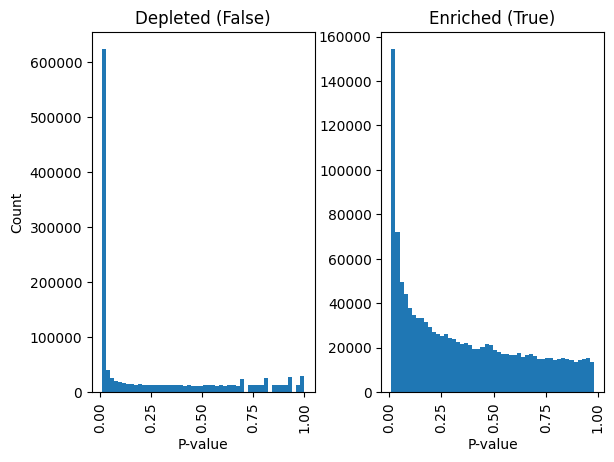

In [25]:
def plot_ppr_enrichment_histograms(fdr_controlled_results):

    axes = fdr_controlled_results["p_value"].hist(bins = int(round(N_NULL_SAMPLES/2, 0)), by = fdr_controlled_results["is_enriched"])
    axes[0].set_title("Depleted (False)")
    axes[1].set_title("Enriched (True)")
    axes[0].set_xlabel("P-value")
    axes[0].set_ylabel("Count")
    axes[1].set_xlabel("P-value")

    plt.show()

plot_ppr_enrichment_histograms(fdr_controlled_results)

PPR enrichment histogram for attribute:  sideloaded_proteomics_chisq


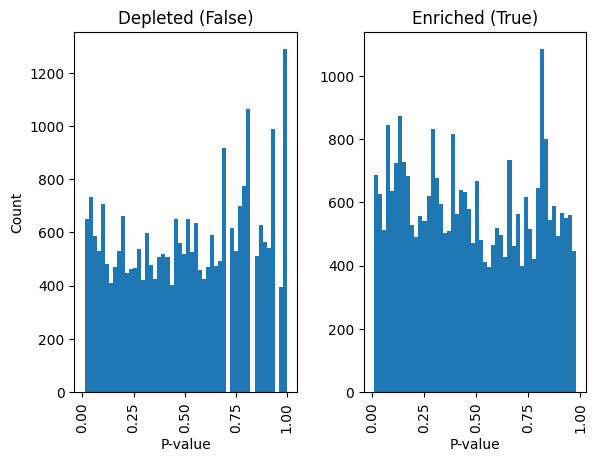

PPR enrichment histogram for attribute:  LF1_proteomics


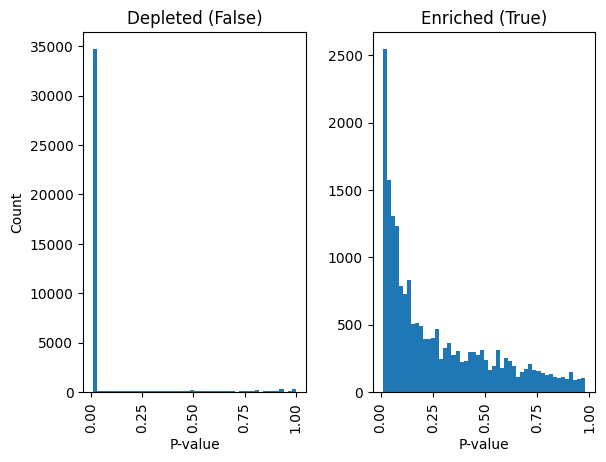

PPR enrichment histogram for attribute:  stat_responsive_to_acute_treatment_transcriptomics


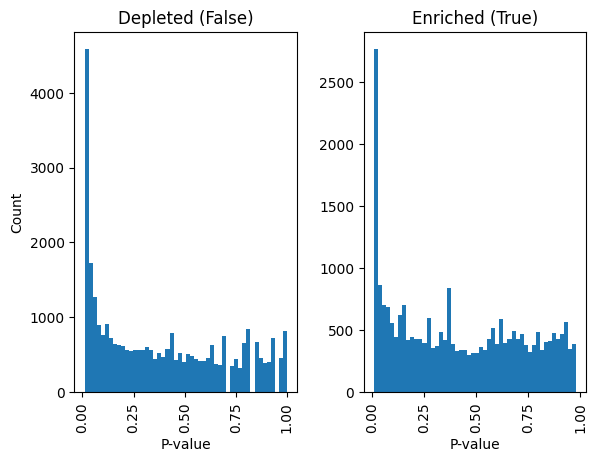

PPR enrichment histogram for attribute:  LF5_proteomics


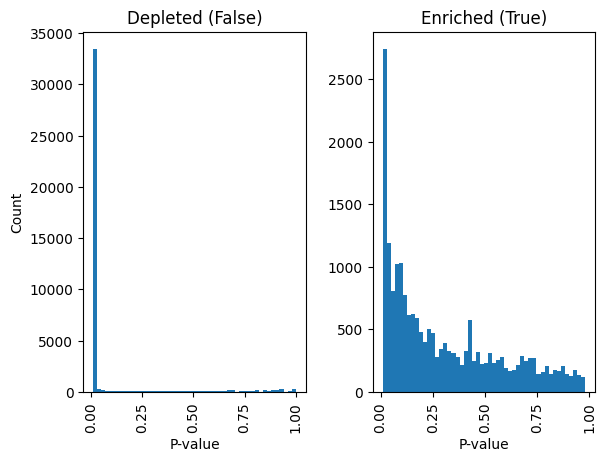

PPR enrichment histogram for attribute:  log10_p_OHCblPlus_transcriptomics


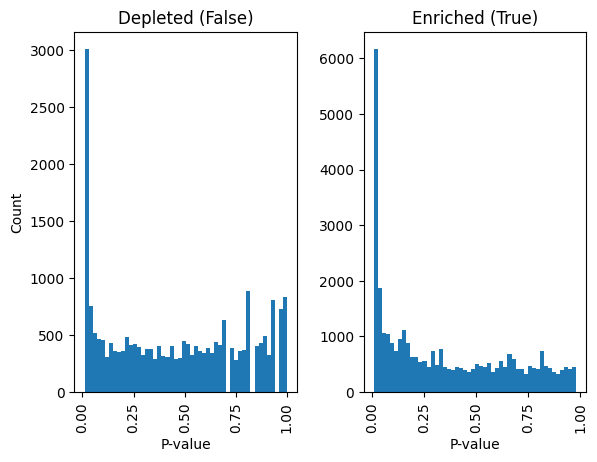

PPR enrichment histogram for attribute:  q_responsive_to_acute_treatment_proteomics


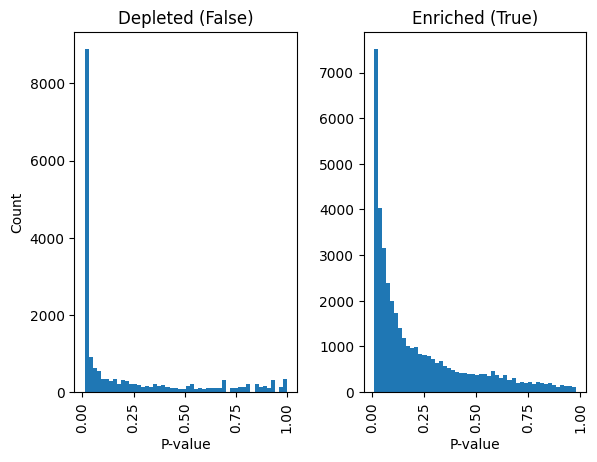

PPR enrichment histogram for attribute:  est_OHCblPlus_proteomics


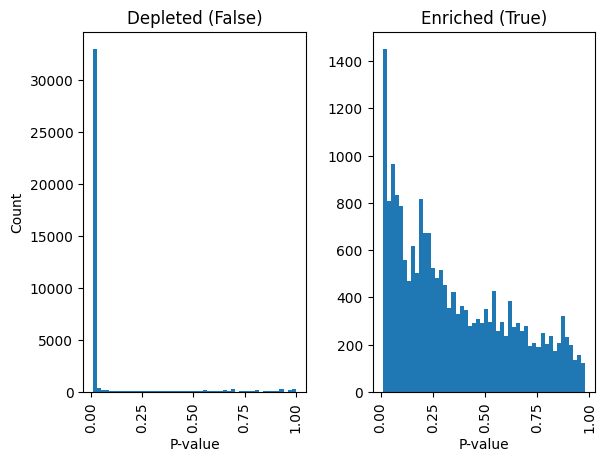

PPR enrichment histogram for attribute:  q_MMA_urine_transcriptomics


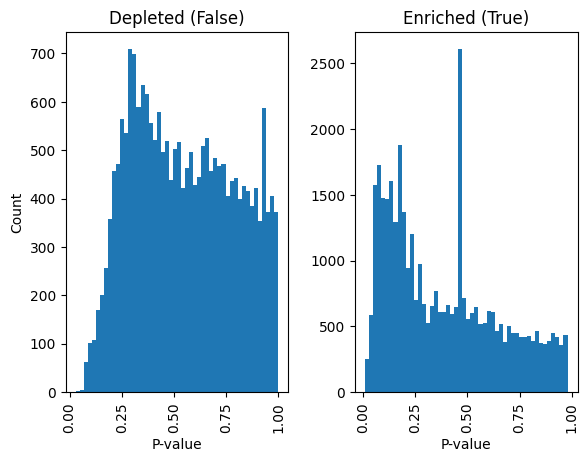

PPR enrichment histogram for attribute:  stat_MMA_urine_transcriptomics


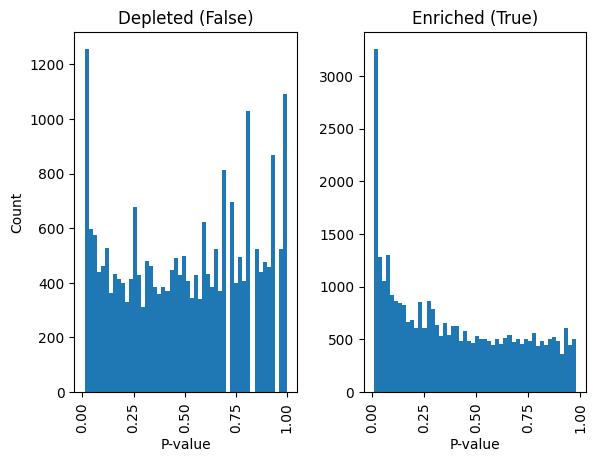

PPR enrichment histogram for attribute:  LF5_transcriptomics


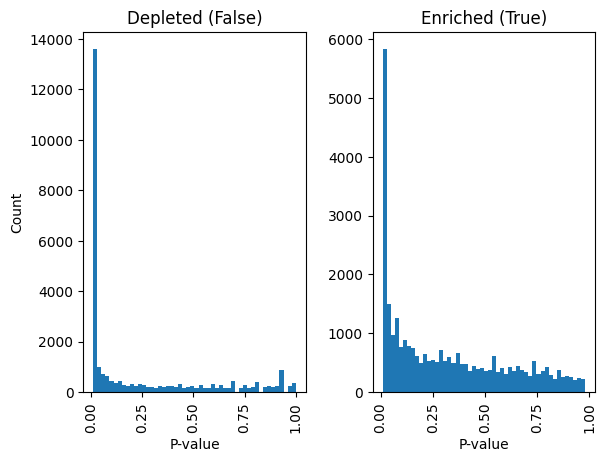

In [26]:
# sample some random attributes

sample_attributes = np.random.choice(fdr_controlled_results["attribute"].unique(), size = 10, replace = False)

for attr in sample_attributes:
    print("PPR enrichment histogram for attribute: ", attr)
    plot_ppr_enrichment_histograms(fdr_controlled_results[fdr_controlled_results["attribute"] == attr])

### Discovery Counts by Attribute

In [27]:
n_enriched_vertices = fdr_controlled_results.query("is_enriched == True").query("q_value < 0.1").value_counts("attribute")

# add back zeros
missing_attributes = set(fdr_controlled_results["attribute"].unique()) - set(n_enriched_vertices.index.tolist())
missing_attributes

n_enriched_vertices = (
    pd.concat([
        n_enriched_vertices,
        pd.Series({attr: 0 for attr in missing_attributes}).rename("count")
    ])
)

# reformat the attributes to include modality and measure
attr_metadata = dict()
for key in n_enriched_vertices.index.tolist():
    for mod in mdata.mod_names:
        # match str
        if re.search(mod, key):
            attr_metadata[key] = {
                "modality" : mod,
                "measure" : re.sub(f"_{mod}", "", key)
            }
            break

    if key not in attr_metadata:
        attr_metadata[key] = {
            "modality" : "unknowm",
            "measure" : key
        }

attr_signif_counts = pd.concat(
    [
        n_enriched_vertices,
        pd.DataFrame(attr_metadata).T
    ],
    axis = 1
)


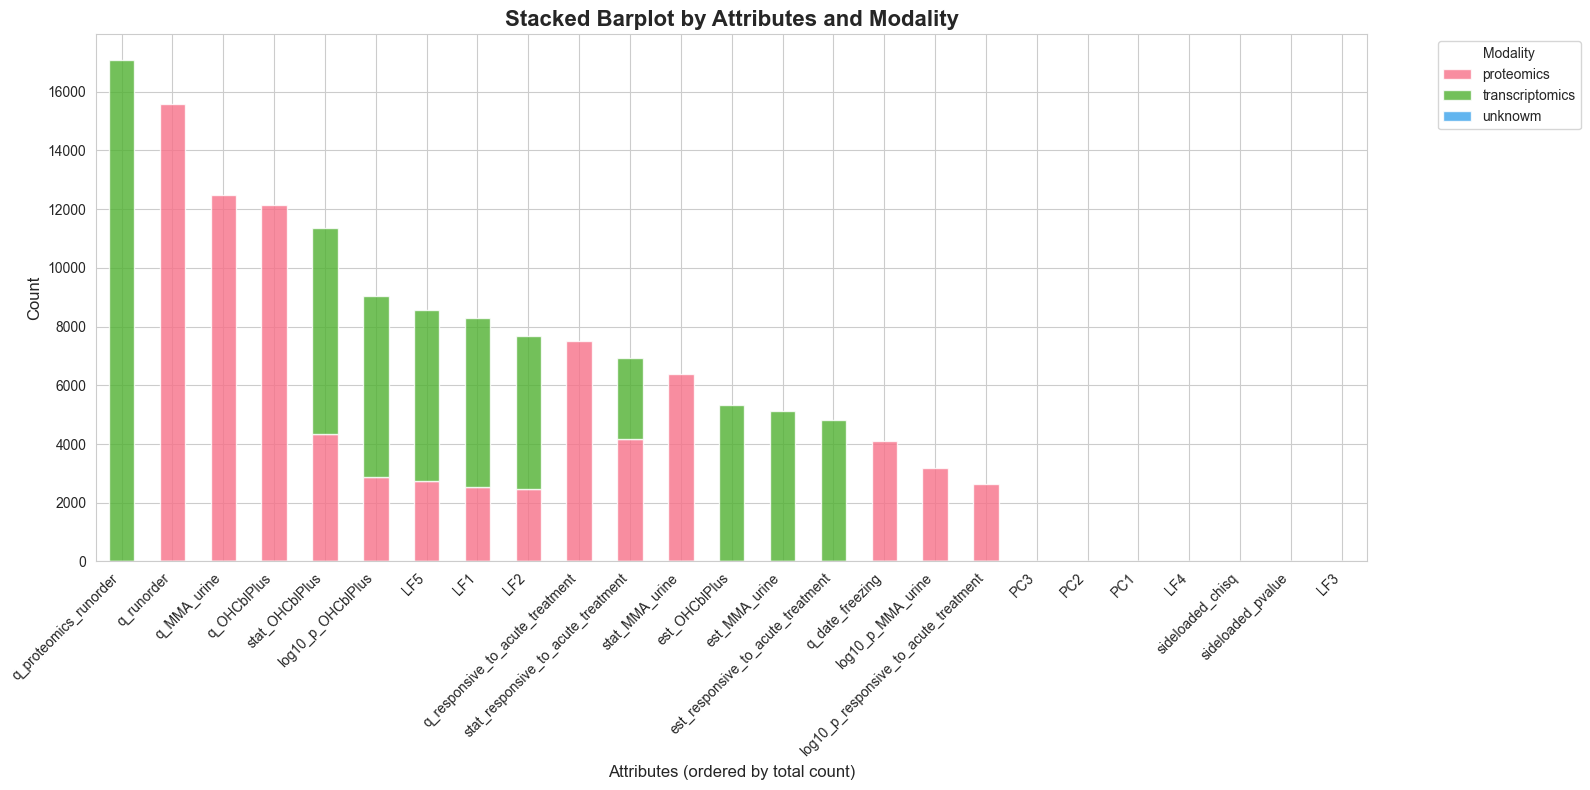

In [28]:

def create_stacked_barplot_seaborn(df):
    """
    Alternative version using seaborn styling
    """
    # Set seaborn style
    sns.set_style("whitegrid")
    
    # Group by measure and sum counts across modalities
    total_counts = df.groupby('measure')['count'].sum().sort_values(ascending=False)
    
    # Create pivot table
    pivot_df = df.pivot_table(index='measure', columns='modality', values='count', fill_value=0)
    pivot_df = pivot_df.reindex(total_counts.index)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Use seaborn color palette
    colors = sns.color_palette("husl", len(pivot_df.columns))
    
    # Plot stacked bars
    pivot_df.plot(kind='bar', stacked=True, ax=ax, color=colors, alpha=0.8)
    
    # Customize
    ax.set_title('Stacked Barplot by Attributes and Modality', fontsize=16, fontweight='bold')
    ax.set_xlabel('Attributes (ordered by total count)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(title='Modality', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return fig, ax

# Example usage:
fig, ax = create_stacked_barplot_seaborn(attr_signif_counts)

### Biological Interpretation

To select for interesting features, we can compare PPR scores to a suitable null distribution. The currently implemented way of doing this to compare:
    - **pagerank_by_attribute** the personalized pagerank scores of vertices when reset probability is proportional to a vertex attribute
    - **pagerank_unifrom** the peronsalized ragerank scores when reset probability is Unfiform over vertices with a non-zero value of the vertex attribute.

This can help to address connectivity biases or if measured vertices show up in a certain region of the network. For example, we may expect metabolites to be nearby other metabolites.

In [29]:
top_enrichments =(
    fdr_controlled_results
    .query("is_enriched == True")
    .query("q_value < 0.1")
    .sort_values(["p_value", "ppr_score"], ascending = [True, False])
    .groupby("attribute")
    .head(10)
    .merge(
        annotated_vertices[["name", "node_name", "node_type"]],
        left_on = "vertex_name",
        right_on = "name"
    )
)

for k, v in top_enrichments.groupby("attribute"):
    print(k)
    display(napistu_utils.style_df(v.head(10)))

LF1_proteomics


,vertex_name,attribute,ppr_score,ppr_null_quantile,p_value,is_enriched,q_value,name,node_name,node_type
0,SC00003692,LF1_proteomics,0.006,1.000,0.010,True,0.075,SC00003692,HBEGF:EGFR:p-Y525-GPNMB:LINC01139:PTK6:LRRK2,species
1,SC00003687,LF1_proteomics,0.005,1.000,0.010,True,0.075,SC00003687,HBEGF:EGFR:GPNMB,species
2,SC00003688,LF1_proteomics,0.005,1.000,0.010,True,0.075,SC00003688,HBEGF:EGFR:p-Y525-GPNMB,species
3,R00646253,LF1_proteomics,0.004,1.000,0.010,True,0.075,R00646253,Phosphorylated GPNMB recruits PTK6 and LRRK2 in the presence of LINC01139,reaction
4,SC00013689,LF1_proteomics,0.003,1.000,0.010,True,0.075,SC00013689,glycogen-GYG1 dimer,species
7,SC00001744,LF1_proteomics,0.003,1.000,0.010,True,0.075,SC00001744,Superoxide anion,species
10,SC00000160,LF1_proteomics,0.003,1.000,0.010,True,0.075,SC00000160,NAD+,species
11,SC00002056,LF1_proteomics,0.003,1.000,0.010,True,0.075,SC00002056,SOD2 tetramer,species
14,R00006385,LF1_proteomics,0.003,1.000,0.010,True,0.075,R00006385,LINC01139 facilitates PTK6 autophosphorylation,reaction
16,SC00000156,LF1_proteomics,0.002,1.000,0.010,True,0.075,SC00000156,NADH,species


LF1_transcriptomics


,vertex_name,attribute,ppr_score,ppr_null_quantile,p_value,is_enriched,q_value,name,node_name,node_type
25,SC00005888,LF1_transcriptomics,0.002,1.000,0.010,True,0.053,SC00005888,SERPINE1 gene,species
40,SC00031023,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00031023,transmembrane protein 176B [cellular_component],species
84,SC00013329,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00013329,PTGDS gene,species
85,SC00001943,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00001943,IL6 gene,species
89,SC00006789,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00006789,RRM2 gene,species
90,SC00000994,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00000994,EGR1 gene,species
91,SC00032566,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00032566,complement factor D [cellular_component],species
96,SC00006843,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00006843,TK1 gene,species
97,SC00027993,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00027993,SLC40A1,species
98,SC00034123,LF1_transcriptomics,0.001,1.000,0.010,True,0.053,SC00034123,transmembrane protein 176A [cellular_component],species


LF2_proteomics


...

,vertex_name,attribute,ppr_score,ppr_null_quantile,p_value,is_enriched,q_value,name,node_name,node_type
128,SC00004948,stat_OHCblPlus_transcriptomics,0.001,1.000,0.010,True,0.048,SC00004948,TP53 gene,species
170,SC00004540,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00004540,INS gene,species
176,SC00004523,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00004523,TNF,species
177,SC00002125,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00002125,VEGFA gene,species
181,SC00008134,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00008134,BDNF gene,species
182,SC00004047,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00004047,IL1B gene,species
193,SC00001963,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00001963,EGF gene,species
195,SC00001506,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00001506,CDH11 gene,species
217,SC00001943,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00001943,IL6 gene,species
222,SC00011386,stat_OHCblPlus_transcriptomics,0.000,1.000,0.010,True,0.048,SC00011386,IGF1,species


stat_responsive_to_acute_treatment_proteomics


,vertex_name,attribute,ppr_score,ppr_null_quantile,p_value,is_enriched,q_value,name,node_name,node_type
70,SC00000160,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00000160,NAD+,species
72,SC00000156,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00000156,NADH,species
106,SC00000252,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00000252,Ac-CoA,species
127,SC00001357,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00001357,L-Glu,species
134,SC00000838,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00000838,Hydrogen peroxide,species
145,SC00000064,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00000064,UDP,species
149,SC00001995,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00001995,2OG,species
155,SC00002325,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00002325,Protonated Carbamino DeoxyHbA,species
156,SC00002330,stat_responsive_to_acute_treatment_proteomics,0.001,1.000,0.010,True,0.049,SC00002330,OxyHbA,species
159,SC00000020,stat_responsive_to_acute_treatment_proteomics,0.000,1.000,0.010,True,0.049,SC00000020,ATP,species


stat_responsive_to_acute_treatment_transcriptomics


,vertex_name,attribute,ppr_score,ppr_null_quantile,p_value,is_enriched,q_value,name,node_name,node_type
162,SC00010855,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00010855,VWF,species
163,SC00001304,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00001304,CDKN1A gene,species
168,SC00001574,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00001574,MYC mRNA,species
179,SC00001741,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00001741,CDKN2A gene,species
192,SC00004677,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00004677,PLK1 Gene,species
223,SC00027269,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00027269,BPTF,species
225,SC00000994,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00000994,EGR1 gene,species
227,SC00033018,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00033018,chromodomain Y like 2 [cellular_component],species
228,SC00004774,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00004774,DNMT1 mRNA,species
233,SC00023563,stat_responsive_to_acute_treatment_transcriptomics,0.000,1.000,0.010,True,0.090,SC00023563,ras homolog family member D [cellular_component],species


## Save Results

In [ ]:
fdr_controlled_results.to_csv(PPR_RESULTS_PATH, sep = "\t")
annotated_vertices.to_csv(ANNOTATED_VERTICES_PATH, sep = "\t")
sbml_dfs.to_pickle(SBML_DFS_W_DATA_PATH)
# re-reversing the graph so its directionality is the same as the initial graph but it has the vertex data we added
working_napistu_graph.reverse_edges()
working_napistu_graph.to_pickle(NAPISTU_GRAPH_W_DATA_PATH)